01. Load & Encode Label

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load data clean
df = pd.read_csv('../data/data_clean.csv')

# Encode label: ham=0, spam=1
df['label_enc'] = df['label'].map({'ham': 0, 'spam': 1})

print("Label encoding:")
print(df[['label', 'label_enc']].drop_duplicates())
print("\nShape:", df.shape)

Label encoding:
  label  label_enc
0   ham          0
2  spam          1

Shape: (5566, 4)


02. Split data

In [2]:
X = df['text_clean']
y = df['label_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,       # 80% train, 20% test
    random_state=42,     # supaya hasil reproducible
    stratify=y           # jaga proporsi spam/ham di train & test
)

print("Ukuran data:")
print(f"  Train: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Test : {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nDistribusi spam di train: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Distribusi spam di test : {y_test.sum()} ({y_test.mean()*100:.1f}%)")

Ukuran data:
  Train: 4452 (80.0%)
  Test : 1114 (20.0%)

Distribusi spam di train: 597 (13.4%)
Distribusi spam di test : 150 (13.5%)


03. TD-IDF Vectorization

In [3]:
# Inisialisasi TF-IDF
tfidf = TfidfVectorizer(
    max_features=5000,   # ambil 5000 kata paling informatif
    ngram_range=(1, 2),  # unigram + bigram (ex: "free" dan "free prize")
    min_df=2             # abaikan kata yang muncul kurang dari 2 dokumen
)

# Fit HANYA pada train, transform keduanya
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Shape TF-IDF matrix:")
print(f"  Train: {X_train_tfidf.shape}")
print(f"  Test : {X_test_tfidf.shape}")

# Lihat contoh fitur yang dihasilkan
print("\n20 fitur pertama:")
print(tfidf.get_feature_names_out()[:20])

Shape TF-IDF matrix:
  Train: (4452, 5000)
  Test : (1114, 5000)

20 fitur pertama:
['aah' 'abi' 'abiola' 'abl' 'abl deliv' 'abl get' 'abl pay' 'abt' 'abt ur'
 'abta' 'abta complimentari' 'aburo' 'aburo enjoy' 'abus' 'ac' 'acc'
 'accept' 'accept brother' 'accept dayu' 'access']


04. Training Model

In [4]:
# Training Logistic Regression
model = LogisticRegression(
    class_weight='balanced',  # kompensasi imbalanced dataset
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

print("Model selesai ditraining.")
print(f"Jumlah fitur: {model.n_features_in_}")

Model selesai ditraining.
Jumlah fitur: 5000


05. Evaluation Model

=== Classification Report ===
              precision    recall  f1-score   support

         ham       0.99      0.98      0.98       964
        spam       0.88      0.92      0.90       150

    accuracy                           0.97      1114
   macro avg       0.94      0.95      0.94      1114
weighted avg       0.97      0.97      0.97      1114



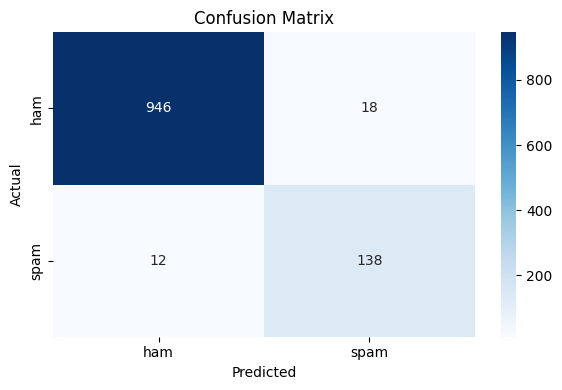

In [5]:
# Prediksi
y_pred = model.predict(X_test_tfidf)

# Classification Report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham', 'spam'],
            yticklabels=['ham', 'spam'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

06. Example Word

In [6]:
import numpy as np

feature_names = tfidf.get_feature_names_out()
coef = model.coef_[0]

# Top 10 kata → spam
top_spam_idx = np.argsort(coef)[-10:][::-1]
print("=== Top 10 kata → SPAM ===")
for idx in top_spam_idx:
    print(f"  {feature_names[idx]:<25} {coef[idx]:.3f}")

# Top 10 kata → ham
top_ham_idx = np.argsort(coef)[:10]
print("\n=== Top 10 kata → HAM ===")
for idx in top_ham_idx:
    print(f"  {feature_names[idx]:<25} {coef[idx]:.3f}")

=== Top 10 kata → SPAM ===
  txt                       5.780
  free                      4.275
  claim                     3.888
  mobil                     3.877
  text                      3.832
  repli                     3.788
  call                      3.643
  stop                      3.376
  prize                     3.099
  servic                    3.068

=== Top 10 kata → HAM ===
  ltgt                      -2.430
  ok                        -2.233
  im                        -2.104
  ill                       -2.009
  home                      -1.634
  hey                       -1.479
  got                       -1.465
  later                     -1.447
  sorri                     -1.431
  say                       -1.425
